# Práctica Final Deep Learning & Computer Vision

Dataset HAM10000. Hay que clasificar el tipo de lesion de la piel (7 clases) usando datos e imagenes.

Hago los 4 modelos que pide la practica:

1. Modelo con datos (tabular)
2. Modelo con imagenes (CNN)
3. Late-fusion
4. Early-fusion

## Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Input, Concatenate
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split

## Carga de datos

Cargo los dos ficheros. Los dos van en el mismo orden, asi que la fila i de uno es la fila i del otro.

In [2]:
metadata = pd.read_csv("HAM10000_metadata.csv")
hmnist = pd.read_csv("hmnist_28_28_RGB.csv")

print(metadata.shape)
print(hmnist.shape)

(10015, 7)
(10015, 2353)


## Exploración del dataset

Examino un poco los datos antes de entrenar.

In [ ]:
print("Numero de muestras:", metadata.shape[0])
print("Columnas:", list(metadata.columns))

print()
print(metadata.dtypes)

Numero de muestras: 10015
Columnas: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

lesion_id        object
image_id         object
dx               object
dx_type          object
age             float64
sex              object
localization     object
dtype: object


In [ ]:
metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
print(metadata.isnull().sum())

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64


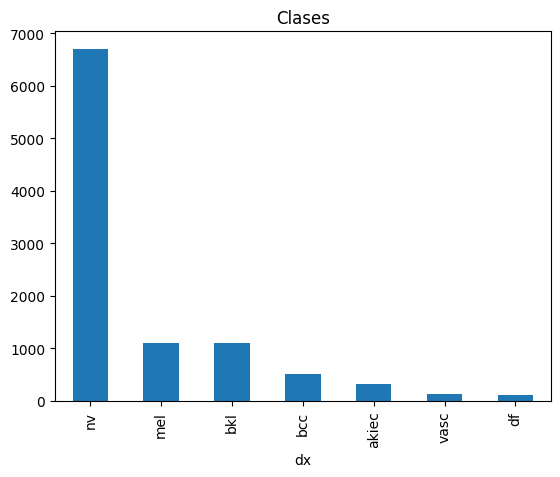

In [ ]:
# veo cuántas imágenes hay de cada clase
metadata["dx"].value_counts().plot(kind="bar")
plt.title("Clases")
plt.show()

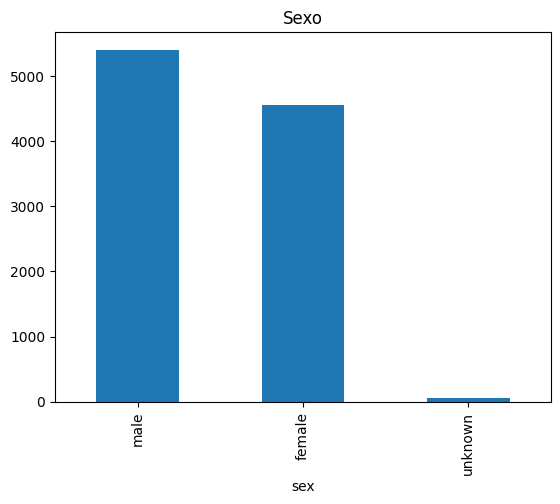

In [7]:
# por sexo
metadata["sex"].value_counts().plot(kind="bar")
plt.title("Sexo")
plt.show()

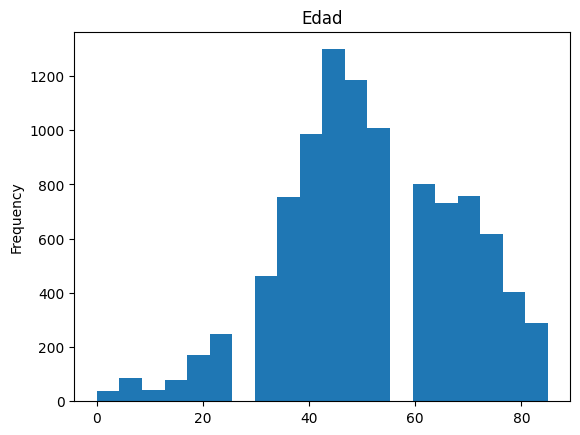

In [8]:
# por edad
metadata["age"].plot(kind="hist", bins=20)
plt.title("Edad")
plt.show()

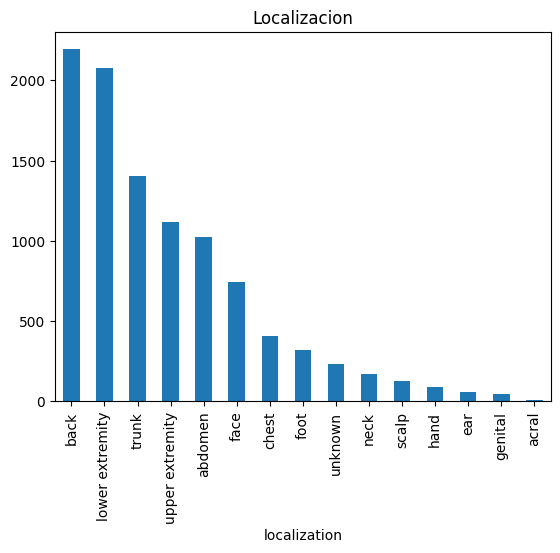

In [9]:
# por localizacion
metadata["localization"].value_counts().plot(kind="bar")
plt.title("Localizacion")
plt.show()

## Preprocesado

In [10]:
# la etiqueta la saco del fichero de imagenes
y = hmnist["label"].values
y = to_categorical(y, num_classes=7)

# las imagenes son el resto de columnas, las paso a 28x28x3 y las divido entre 255
X_img = hmnist.drop("label", axis=1).values
X_img = X_img.reshape(-1, 28, 28, 3) / 255.0

In [11]:
# me quedo solo con sexo, edad y localizacion
tabular = metadata[["sex", "age", "localization"]].copy()

# relleno la edad que falta con la media y la normalizo
tabular["age"] = tabular["age"].fillna(tabular["age"].mean())
tabular["age"] = tabular["age"] / tabular["age"].max()

# paso sexo y localizacion a numeros
tabular = pd.get_dummies(tabular, columns=["sex", "localization"])

X_tab = tabular.values.astype("float32")

In [12]:
# separo en train y test
X_tab_train, X_tab_test, X_img_train, X_img_test, y_train, y_test = train_test_split(
    X_tab, X_img, y, test_size=0.2, random_state=42)

## Modelo 1: Datos tabulares

Una red sencilla que solo usa sexo, edad y localizacion.

In [13]:
modelo_tabular = Sequential([
    Dense(64, activation="relu", input_shape=(X_tab_train.shape[1],)),
    Dense(32, activation="relu", name="tabular_features"),
    Dense(7, activation="softmax")
])

modelo_tabular.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

H1 = modelo_tabular.fit(X_tab_train, y_train,
                   validation_data=(X_tab_test, y_test),
                   epochs=10, batch_size=128)

Epoch 1/10


c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6531 - loss: 1.3864 - val_accuracy: 0.6680 - val_loss: 1.1393
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6699 - loss: 1.0843 - val_accuracy: 0.6680 - val_loss: 1.0438
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6857 - loss: 1.0140 - val_accuracy: 0.6920 - val_loss: 0.9858
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6942 - loss: 0.9640 - val_accuracy: 0.6950 - val_loss: 0.9482
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6990 - loss: 0.9359 - val_accuracy: 0.6975 - val_loss: 0.9171
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7004 - loss: 0.9233 - val_accuracy: 0.6975 - val_loss: 0.9126
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6993 - loss: 0.9198 - val_accuracy: 0.6945 - val_loss: 0.9041
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6986 - loss: 0.9142 - val_accuracy: 0.6920 - val_loss: 0.9036
Epo

In [14]:
modelo_tabular.evaluate(X_tab_test, y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6930 - loss: 0.8987


[0.8987266421318054, 0.6929605603218079]

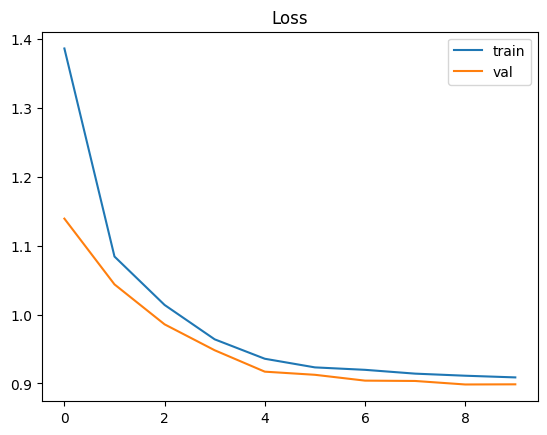

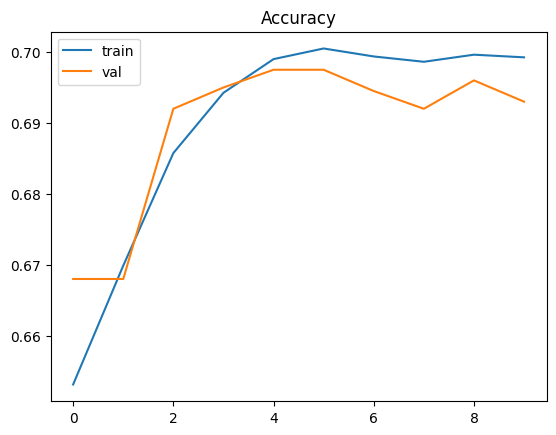

In [15]:
# graficas del modelo 1
plt.plot(H1.history["loss"], label="train")
plt.plot(H1.history["val_loss"], label="val")
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(H1.history["accuracy"], label="train")
plt.plot(H1.history["val_accuracy"], label="val")
plt.legend()
plt.title("Accuracy")
plt.show()

## Modelo 2: Imágenes (CNN)

Una CNN sencilla que solo usa las imagenes.

In [16]:
modelo_cnn = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 3)),
    MaxPooling2D(),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(),
    Flatten(),
    Dense(64, activation="relu", name="vision_features"),
    Dense(7, activation="softmax")
])

modelo_cnn.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

H2 = modelo_cnn.fit(X_img_train, y_train,
               validation_data=(X_img_test, y_test),
               epochs=10, batch_size=128)

Epoch 1/10


c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6634 - loss: 1.1134 - val_accuracy: 0.6680 - val_loss: 1.0322
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6746 - loss: 0.9557 - val_accuracy: 0.6680 - val_loss: 0.9299
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6845 - loss: 0.8851 - val_accuracy: 0.6795 - val_loss: 0.8861
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6906 - loss: 0.8563 - val_accuracy: 0.6870 - val_loss: 0.8669
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7006 - loss: 0.8288 - val_accuracy: 0.6955 - val_loss: 0.8391
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7033 - loss: 0.8056 - val_accuracy: 0.6895 - val_loss: 0.8373
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7112 - loss: 0.7910 - val_accuracy: 0.6940 - val_loss: 0.8075
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7174 - loss: 0.7725 - val_accuracy: 0.6955 - val_loss: 0.

In [17]:
modelo_cnn.evaluate(X_img_test, y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7289 - loss: 0.7522


[0.752170979976654, 0.7289066314697266]

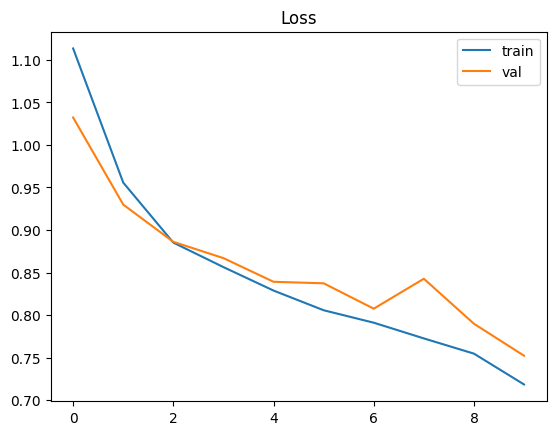

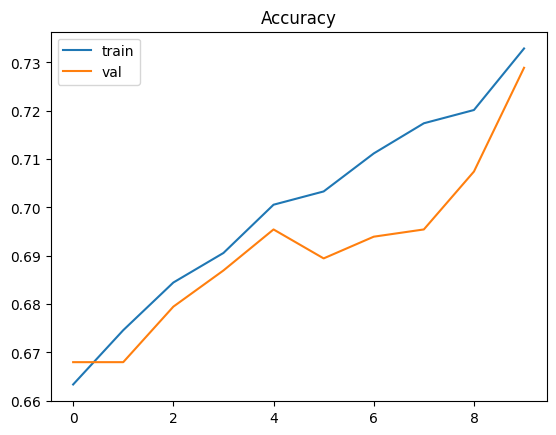

In [18]:
# graficas del modelo 2
plt.plot(H2.history["loss"], label="train")
plt.plot(H2.history["val_loss"], label="val")
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(H2.history["accuracy"], label="train")
plt.plot(H2.history["val_accuracy"], label="val")
plt.legend()
plt.title("Accuracy")
plt.show()

## Modelo 3: Late-fusion

En este modelo utilizo las predicciones de los dos modelos anteriores y las combino con una capa Dense para obtener la predicción final. Los dos modelos se mantienen congelados para entrenar únicamente esa capa.

In [ ]:
modelo_tabular.trainable = False
modelo_cnn.trainable = False

tabular_input = Input(shape=(X_tab_train.shape[1],))
vision_input = Input(shape=(28, 28, 3))

tabular_pred = modelo_tabular(tabular_input)
vision_pred = modelo_cnn(vision_input)

merged = Concatenate()([tabular_pred, vision_pred])
output = Dense(7, activation="softmax")(merged)

modelo_late = Model(inputs=[tabular_input, vision_input], outputs=output)
modelo_late.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

H3 = modelo_late.fit([X_tab_train, X_img_train], y_train,
                validation_data=([X_tab_test, X_img_test], y_test),
                epochs=10, batch_size=128)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0191 - loss: 2.0645 - val_accuracy: 0.0559 - val_loss: 1.9553
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1535 - loss: 1.8669 - val_accuracy: 0.2936 - val_loss: 1.7700
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5401 - loss: 1.6925 - val_accuracy: 0.6680 - val_loss: 1.6100
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6699 - loss: 1.5441 - val_accuracy: 0.6680 - val_loss: 1.4753
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6699 - loss: 1.4209 - val_accuracy: 0.6680 - val_loss: 1.3656
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6699 - loss: 1.3207 - val_accuracy: 0.6680 - val_loss: 1.2769
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6699 - loss: 1.2396 - val_accuracy: 0.6680 - val_loss: 1.2053
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6699 - loss: 1.1741 - val_accuracy: 0.6680 - val_loss:

In [20]:
modelo_late.evaluate([X_tab_test, X_img_test], y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6680 - loss: 1.0602


[1.0602483749389648, 0.6679980158805847]

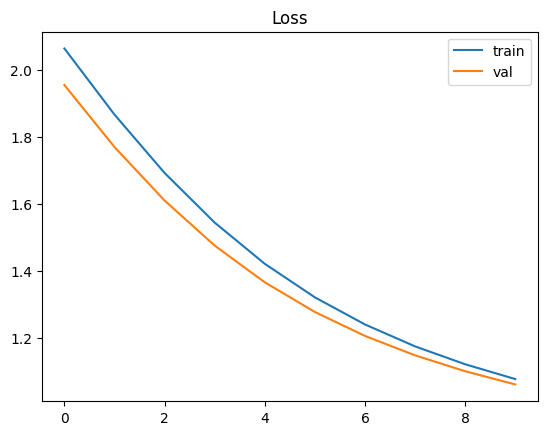

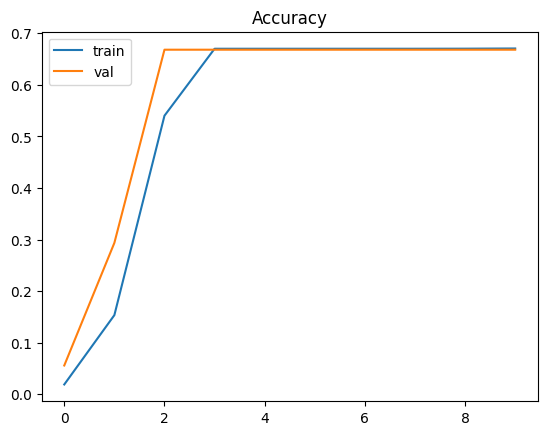

In [21]:
# graficas del modelo 3
plt.plot(H3.history["loss"], label="train")
plt.plot(H3.history["val_loss"], label="val")
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(H3.history["accuracy"], label="train")
plt.plot(H3.history["val_accuracy"], label="val")
plt.legend()
plt.title("Accuracy")
plt.show()

## Modelo 4: Early-fusion

En este modelo, en vez de juntar las predicciones de los dos modelos, junto las características que aprende cada uno antes de la última capa. Después paso esa información por varias capas Dense para obtener la clasificación final.

In [34]:
tabular_input = Input(shape=(X_tab_train.shape[1],))
vision_input = Input(shape=(28, 28, 3))

x_tab = modelo_tabular.layers[0](tabular_input)
tabular_features = modelo_tabular.layers[1](x_tab)

x_img = modelo_cnn.layers[0](vision_input)
x_img = modelo_cnn.layers[1](x_img)
x_img = modelo_cnn.layers[2](x_img)
x_img = modelo_cnn.layers[3](x_img)
x_img = modelo_cnn.layers[4](x_img)
vision_features = modelo_cnn.layers[5](x_img)

# junto las caracteristicas y pongo un clasificador
merged = Concatenate()([tabular_features, vision_features])
x = Dense(64, activation="relu")(merged)
output = Dense(7, activation="softmax")(x)

modelo_early = Model(inputs=[tabular_input, vision_input], outputs=output)
modelo_early.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

H4 = modelo_early.fit([X_tab_train, X_img_train], y_train,
                 validation_data=([X_tab_test, X_img_test], y_test),
                 epochs=10, batch_size=128)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6706 - loss: 0.9622 - val_accuracy: 0.7304 - val_loss: 0.7815
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7459 - loss: 0.7176 - val_accuracy: 0.7459 - val_loss: 0.7078
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7604 - loss: 0.6577 - val_accuracy: 0.7504 - val_loss: 0.6691
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7681 - loss: 0.6286 - val_accuracy: 0.7544 - val_loss: 0.6517
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7752 - loss: 0.6095 - val_accuracy: 0.7624 - val_loss: 0.6450
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7768 - loss: 0.5993 - val_accuracy: 0.7614 - val_loss: 0.6374
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7801 - loss: 0.5938 - val_accuracy: 0.7599 - val_loss: 0.6422
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7801 - loss: 0.5852 - val_accuracy: 0.7698 - val_loss:

In [35]:
modelo_early.evaluate([X_tab_test, X_img_test], y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7624 - loss: 0.6312


[0.6312345266342163, 0.7623564600944519]

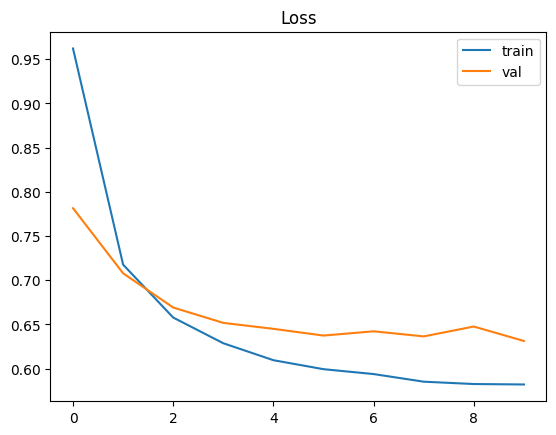

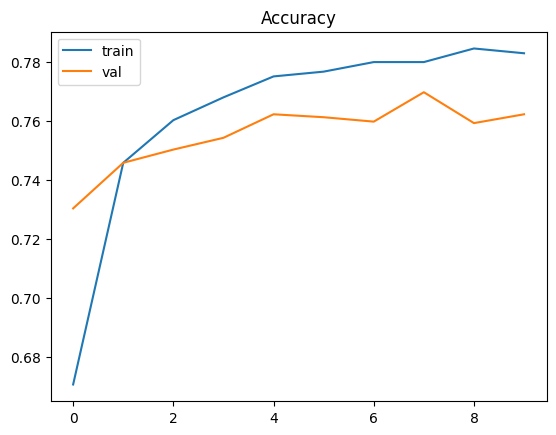

In [36]:
# graficas del modelo 4
plt.plot(H4.history["loss"], label="train")
plt.plot(H4.history["val_loss"], label="val")
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(H4.history["accuracy"], label="train")
plt.plot(H4.history["val_accuracy"], label="val")
plt.legend()
plt.title("Accuracy")
plt.show()

## Comparativa final

Pongo juntos el accuracy y el loss de los 4 modelos para ver cual va mejor.

In [25]:
# saco el loss y el accuracy de cada modelo
loss1, acc1 = modelo_tabular.evaluate(X_tab_test, y_test, verbose=0)
loss2, acc2 = modelo_cnn.evaluate(X_img_test, y_test, verbose=0)
loss3, acc3 = modelo_late.evaluate([X_tab_test, X_img_test], y_test, verbose=0)
loss4, acc4 = modelo_early.evaluate([X_tab_test, X_img_test], y_test, verbose=0)

comparativa = pd.DataFrame({
    "Modelo": ["Tabular", "CNN", "Late-fusion", "Early-fusion"],
    "Accuracy": [acc1, acc2, acc3, acc4],
    "Loss": [loss1, loss2, loss3, loss4]
})

comparativa

,Modelo,Accuracy,Loss
0,Tabular,0.692961,0.898727
1,CNN,0.728907,0.752171
2,Late-fusion,0.667998,1.060248
3,Early-fusion,0.766350,0.636661


## Conclusiones

El que mejor me ha salido es el Early-fusion, tiene el accuracy mas alto y el loss mas bajo. Creo que es porque junta las imagenes y los datos desde el principio y asi usa las dos cosas a la vez. El tabular solo es el que peor va porque con sexo, edad y localizacion no hay mucha info. La CNN va bastante bien porque la imagen dice mas. El late-fusion no me mejora mucho porque solo junta las predicciones del final.

## Ejemplo de clasificación

Cojo una muestra del test y miro que clase dice el mejor modelo (el early-fusion) y la comparo con la clase real.

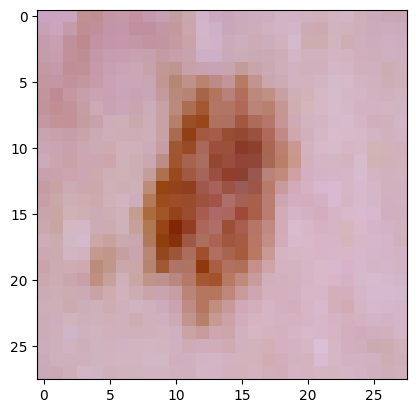

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Clase real: 6
Clase predicha: 4


In [ ]:
# Modificar variable i para cambiar la muestra que se quiere predecir
i = 18
img = X_img_test[i]
tab = X_tab_test[i]

plt.imshow(img)
plt.show()

pred = modelo_early.predict([tab.reshape(1, -1), img.reshape(1, 28, 28, 3)])
clase_predicha = pred.argmax()
clase_real = y_test[i].argmax()

print("Clase real:", clase_real)
print("Clase predicha:", clase_predicha)